## spotify 2023 dataset  

https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023?resource=download  

## 1. Data Processing

### Process the target variable (popularity classification)

**Objective**: Treat popularity as a binary classification task.  
Since the dataset does not have a predefined popularity label, we define it using the **streams (number of plays)** as a proxy.  

Instead of a fixed threshold (e.g., 100M streams), we use **the 75th percentile (Q3)** as the threshold:  
- **Popular songs (1)**: Songs with `streams ≥ Q3`
- **Non-popular songs (0)**: Songs with `streams < Q3`  

This ensures the definition is **data-driven**, avoiding arbitrary cutoffs.

### Process categorical features

- **key**: Convert to numerical using **Label Encoding** (`key_encoded`).
- **mode**: Convert `"Major"` → `1`, `"Minor"` → `0`.
- **artist_count, released_year**: Kept as numerical features.

### Handle missing values

- **key**: Missing values are replaced with `"Unknown"`.
- **in_shazam_charts**: Missing values are set to `0`, assuming they did not appear in the charts.

### Handle outliers

- **Streams, bpm, danceability_%, energy_%, etc.**:  
  - Use **IQR (Interquartile Range) method** to clip extreme values and reduce skewness.

### Remove unnecessary fields

- **track_name, artist(s)_name**: These fields are not useful for classification and are removed.

### Normalize numerical features

- **StandardScaler** is used to standardize all numerical features, ensuring consistency across models.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the original dataset
file_path = "D:\Gatech\CS7641 Machine Learning\A1\spotify-2023.csv"  # Update this path if necessary
df = pd.read_csv(file_path, encoding="latin1")

# 1. Convert 'streams' to numeric and define the "popular song" classification
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Compute the Q3 (75th percentile) threshold as the popularity cutoff
popularity_threshold = df['streams'].quantile(0.75)
df['popularity'] = (df['streams'] >= popularity_threshold).astype(int)

# 2. Handle missing values
df['key'].fillna('Unknown', inplace=True)  # Fill missing values in 'key' column
df['in_shazam_charts'].fillna(0, inplace=True)  # Fill missing values in 'in_shazam_charts' with 0

# 3. Handle outliers using the IQR method
num_features = ['streams', 'bpm', 'danceability_%', 'valence_%', 'energy_%',
                'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)  # Clip extreme values

# 4. Encode categorical variables
key_to_idx = {key: idx for idx, key in enumerate(df['key'].unique())}
df['key_encoded'] = df['key'].map(key_to_idx)
df['mode'] = df['mode'].map({'Major': 1, 'Minor': 0})

# 5. Select features for training
features = ['artist_count', 'released_year', 'bpm', 'danceability_%', 'valence_%',
            'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%',
            'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts',
            'key_encoded', 'mode']

# 6. Normalize features using StandardScaler for consistency across models
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# 7. Split the dataset into training (80%) and testing (20%) sets
train_df, test_df = train_test_split(df[features + ['popularity']], test_size=0.2, random_state=42)

# 8. Save the processed datasets
train_df.to_csv("train_processed.csv", index=False)
test_df.to_csv("test_processed.csv", index=False)

print("Data preprocessing completed. Training and testing datasets are saved.")


## 2. Neural Network Training and Hyperparameter Tuning

### 2.1 Model Architecture
- **Input Layer**: 16 features from the processed dataset
- **Hidden Layers**:
  1. Layer 1: 64 neurons, configurable activation (`ReLU`, `Tanh`, or `Sigmoid`), Dropout = 0.5
  2. Layer 2: 64 neurons, same configurable activation, Dropout = 0.5
  3. Layer 3: 64 neurons, same configurable activation, no Dropout
- **Output Layer**: 1 neuron with `Sigmoid` activation for binary classification
- **L2 regularization** is applied via `weight_decay=1e-3` in the optimizer to help prevent overfitting.


### 2.2 Training Strategy
- **Activation Function Experiments**:
  - Tested activations: `ReLU`, `Tanh`, `Sigmoid`
  - Investigate their impact on convergence, error rate
- **Epochs**: 50
- **Metrics Tracked** (every epoch):
  - Training error rate (1 - accuracy)
  - Test error rate (1 - accuracy)


### 2.3 Results Visualization
To compare the effects of different activation functions, we plot:
1. **Training/Test error rate curves**  
   - Show trends in error rate for each activation function over epochs

All y-axes are kept consistent to allow for direct visual comparison.


### 2.4 Code Implementation
Key components in the PyTorch code:
- **Optimizer**: Adam with `weight_decay=1e-3`  
- **Loss Function**: `BCELoss` for binary classification  
- **Regularization**: Dropout layers set to 0.5  
- **Mini-batch Training**: batch size = 64


### 2.5 Analysis and Discussion
- **ReLU & Tanh** typically achieve faster convergence due to reduced vanishing gradient issues.
- **Sigmoid** can lead to slower learning, especially in deeper networks.
- While final error rate differences may be small, ReLU and Tanh generally perform more consistently.
- Using unified y-axis scales enables a fair comparison of error rate curves.


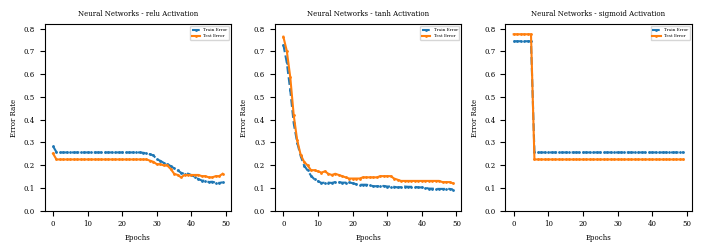

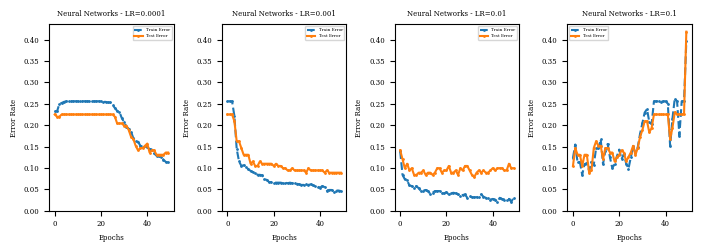

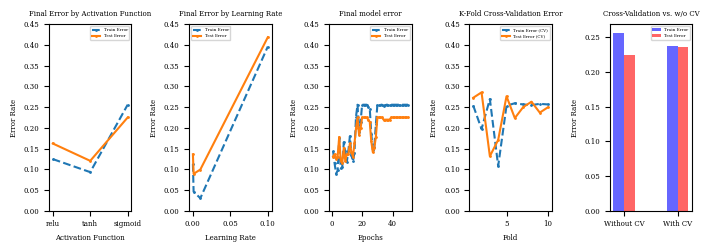

In [37]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import random
import numpy as np
from sklearn.model_selection import KFold
import time


# Create directory for saving results
results_dir = "NN"
os.makedirs(results_dir, exist_ok=True)

# Load training and testing datasets
train_df = pd.read_csv("train_processed.csv")
test_df = pd.read_csv("test_processed.csv")

# Convert to PyTorch tensors
X_train = torch.tensor(train_df.drop(columns=['popularity']).values, dtype=torch.float32)
y_train = torch.tensor(train_df['popularity'].values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(test_df.drop(columns=['popularity']).values, dtype=torch.float32)
y_test = torch.tensor(test_df['popularity'].values, dtype=torch.float32).unsqueeze(1)

# Set random seed for reproducibility
def set_seed(seed=1024):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(1024)

# Define the DNN model
class DNN(nn.Module):
    def __init__(self, input_size, activation='relu'):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        activations = {'relu': nn.ReLU(), 'tanh': nn.Tanh(), 'sigmoid': nn.Sigmoid()}
        self.activation = activations.get(activation, nn.ReLU())
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        x = self.activation(self.fc3(x))
        x = self.sigmoid(self.output(x))
        return x

# Training function
def train_model(activation, lr=0.0001, epochs=50, X_train=None, y_train=None, X_test=None, y_test=None, save_path=None):
    if X_train is None or y_train is None or X_test is None or y_test is None:
        X_train, y_train, X_test, y_test = globals()['X_train'], globals()['y_train'], globals()['X_test'], globals()['y_test']
    
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    model = DNN(input_size=X_train.shape[1], activation=activation)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    
    train_errors, test_errors = [], []
    log_data = []

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            train_preds = (model(X_train) >= 0.5).float()
            test_preds = (model(X_test) >= 0.5).float()

            train_error = 1 - (train_preds.eq(y_train).sum() / len(y_train)).item()
            test_error = 1 - (test_preds.eq(y_test).sum() / len(y_test)).item()

        train_errors.append(train_error)
        test_errors.append(test_error)

        # Save log data
        log_data.append([epoch + 1, train_error, test_error])

    # Save logs to CSV
    if save_path:
        df_log = pd.DataFrame(log_data, columns=['Epoch', 'Train Error', 'Test Error'])
        df_log.to_csv(save_path, index=False)

    return train_errors, test_errors

# Train different activation functions
activations = ['relu', 'tanh', 'sigmoid']
activation_train_errors, activation_test_errors = {}, {}

for act in activations:
    log_path = os.path.join(results_dir, f"train_log_activation_{act}.csv")
    train_error, test_error = train_model(activation=act, save_path=log_path)
    activation_train_errors[act] = train_error
    activation_test_errors[act] = test_error

best_activation = min(activation_test_errors, key=activation_test_errors.get)

# Train different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_train_errors, lr_test_errors = {}, {}

for lr in learning_rates:
    log_path = os.path.join(results_dir, f"train_log_lr_{lr}.csv")
    train_error, test_error = train_model(activation= best_activation, lr=lr, save_path=log_path)
    lr_train_errors[lr] = train_error
    lr_test_errors[lr] = test_error

best_lr = min(lr_test_errors, key=lr_test_errors.get)

# Function to calculate y-limits per figure group
def get_group_ylim(error_dict):
    all_values = [val for sublist in error_dict.values() for val in sublist]
    ymin, ymax = min(all_values), max(all_values)
    return min(0,ymin), ymax * 1.1

# Compute y-axis limits separately for each figure group
ylim_activation = get_group_ylim(activation_train_errors)
ylim_lr = get_group_ylim(lr_train_errors)

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})

# Plot activation functions
fig, axes = plt.subplots(1, 3, figsize=(7,2.5))
for i, act in enumerate(activations):
    axes[i].plot(range(50), activation_train_errors[act], label="Train Error", linestyle='dashed', marker='o')
    axes[i].plot(range(50), activation_test_errors[act], label="Test Error", marker='o')
    axes[i].set_title(f"Neural Networks - {act} Activation")
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Error Rate")
    axes[i].set_ylim(ylim_activation)
    axes[i].legend()
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "Spotify_NN_activation_error_rate.png"), dpi = 300)
plt.show()

# Plot learning rates
fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))
for i, lr in enumerate(learning_rates):
    axes[i].plot(range(50), lr_train_errors[lr], label="Train Error", linestyle='dashed', marker='o')
    axes[i].plot(range(50), lr_test_errors[lr], label="Test Error", marker='o')
    axes[i].set_title(f"Neural Networks - LR={lr}")
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Error Rate")
    axes[i].set_ylim(ylim_lr)
    axes[i].legend()
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "Spotify_NN_lr_error_rate.png"),dpi = 300)
plt.show()


# K-Fold CV
k_folds = 10
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)


def cross_validate_final_model(activation, lr, epochs=50):
    fold_train_errors = []
    fold_test_errors = []
    log_data = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        train_error, test_error = train_model(activation=activation, lr=lr, epochs=epochs,
                                              X_train=X_train_fold, y_train=y_train_fold,
                                              X_test=X_val_fold, y_test=y_val_fold)

        fold_train_errors.append(train_error[-1])
        fold_test_errors.append(test_error[-1])

        # Save fold errors
        log_data.append([fold_idx, train_error, test_error])

    # Save cross-validation logs
    log_path = os.path.join(results_dir, f"cross_validation_log_{activation}_{lr}.csv")
    df_log = pd.DataFrame(log_data, columns=['Fold', 'Train Error', 'Test Error'])
    df_log.to_csv(log_path, index=False)

    cv_train_error = np.mean(fold_train_errors)
    cv_test_error = np.mean(fold_test_errors)

    # print("Fold-wise Train Errors:", fold_train_errors)
    # print("Fold-wise Test Errors:", fold_test_errors)
    # print(f"Final CV Train Error: {cv_train_error}")
    # print(f"Final CV Test Error: {cv_test_error}")

    return cv_train_error, cv_test_error, fold_train_errors, fold_test_errors

# Get the Best Activation Function & Learning Rate**
# best_activation = 'tanh'
# best_lr = 0.01

# Train without Cross-Validation to get best non-CV error**
non_cv_log_path = os.path.join(results_dir, "train_log_non_cv.csv")
start_non_cv = time.time()
best_non_cv_train_error, best_non_cv_test_error = train_model(best_activation, best_lr, save_path=non_cv_log_path)
end_non_cv = time.time()
non_cv_duration = end_non_cv - start_non_cv

# Run Cross-Validation to get CV errors**
start_cv = time.time()
cv_train_error, cv_test_error, cv_train_errors, cv_test_errors = cross_validate_final_model(best_activation, best_lr)
end_cv = time.time()
cv_duration = end_cv - start_cv

# **Save combined results (non-CV and CV) to a single CSV**
final_results = [
    {
        "Model": "Non-CV",
        "Time(s)": non_cv_duration,
        "Train_Error": best_non_cv_train_error[-1] if isinstance(best_non_cv_train_error, list) else best_non_cv_train_error,
        "Test_Error": best_non_cv_test_error[-1] if isinstance(best_non_cv_test_error, list) else best_non_cv_test_error
    },
    {
        "Model": "CV",
        "Time(s)": cv_duration,
        "Train_Error": cv_train_error,
        "Test_Error": cv_test_error
    }
]

pd.DataFrame(final_results).to_csv(os.path.join(results_dir, "dnn_log.csv"), index=False)

# Final Figure Set 3
fig, axes = plt.subplots(1, 5, figsize=(7, 2.5))

# Ensure all subplots share the same y-axis scale
min_error = min(0, min(cv_train_errors), min(cv_test_errors), best_non_cv_train_error[-1], cv_train_error)
max_error = max(0.45, max(cv_train_errors), max(cv_test_errors), best_non_cv_test_error[-1], cv_test_error)

# Subplot 1: Final Error by Activation Function
final_activation_train_errors = [activation_train_errors[act][-1] for act in activations] 
final_activation_test_errors = [activation_test_errors[act][-1] for act in activations]

axes[0].plot(activations, final_activation_train_errors, marker='o', linestyle='dashed', label="Train Error")
axes[0].plot(activations, final_activation_test_errors, marker='o', label="Test Error")
axes[0].set_title("Final Error by Activation Function")
axes[0].set_ylabel("Error Rate")
axes[0].set_xlabel("Activation Function")
axes[0].legend()
axes[0].set_ylim(min_error, max_error)

# **Subplot 2: Final Error by Learning Rate**
final_lr_train_errors = [lr_train_errors[lr][-1] for lr in learning_rates]
final_lr_test_errors = [lr_test_errors[lr][-1] for lr in learning_rates]
axes[1].plot(learning_rates, final_lr_train_errors, marker='o', linestyle='dashed', label="Train Error")
axes[1].plot(learning_rates, final_lr_test_errors, marker='o', label="Test Error")
axes[1].set_title("Final Error by Learning Rate")
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Error Rate")
axes[1].legend()
axes[1].set_ylim(min_error, max_error)

# **Subplot 3: Final model errors**
axes[2].plot(range(1,51), best_non_cv_train_error, marker='o', linestyle='dashed', label="Train Error")
axes[2].plot(range(1,51), best_non_cv_test_error, marker='o', label="Test Error")
axes[2].set_title("Final model error")
axes[2].set_ylabel("Error Rate")
axes[2].set_xlabel("Epochs")
axes[2].legend()
axes[2].set_ylim(min_error, max_error)

# **Subplot 3: K-Fold Cross-Validation Error**
axes[3].plot(range(1, k_folds+1), cv_train_errors, marker='o', linestyle='dashed', label="Train Error (CV)")
axes[3].plot(range(1, k_folds+1), cv_test_errors, marker='o', label="Test Error (CV)")
axes[3].set_title("K-Fold Cross-Validation Error")
axes[3].set_xlabel("Fold")
axes[3].set_ylabel("Error Rate")
axes[3].legend()
axes[3].set_ylim(min_error, max_error)

# **Subplot 4: CV vs. No-CV Bar Chart**
# print("Non-CV Train Error:", best_non_cv_train_error[-1])
# print("Non-CV Test Error:", best_non_cv_test_error[-1])
# print("CV Train Errors median:", np.median(cv_train_errors))
# print("CV Test Errors median:", np.median(cv_test_errors))
# print("CV Train Error:", cv_train_error)
# print("CV Test Error:", cv_test_error)


labels = ["Without CV", "With CV"]
x = np.arange(len(labels))
width = 0.2
axes[4].bar(x - width/2, [best_non_cv_train_error[-1], cv_train_error], width, label="Train Error", color='b', alpha=0.6)
axes[4].bar(x + width/2, [best_non_cv_test_error[-1], cv_test_error], width, label="Test Error", color='r', alpha=0.6)
axes[4].set_title("Cross-Validation vs. w/o CV")
axes[4].set_xticks(x)
axes[4].set_xticklabels(labels)
axes[4].set_ylabel("Error Rate")
axes[4].legend()
# axes[3].set_ylim(min_error, max_error)
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "Spotify_NN_final_comparison_with_cv.png"),dpi = 300)
plt.show()


## 3. K-Nearest Neighbors (KNN) Classification

### 3.1 Overview
In this section, we implement and evaluate the **K-Nearest Neighbors (KNN)** algorithm on the dataset. We analyze the impact of different values of \( k \) (number of neighbors) and **different distance metrics** on model performance.

### 3.2 Data Preprocessing
- **Feature Selection**: We extract the feature matrix and labels, where `popularity` is the target variable.
- **Feature Scaling**: Since KNN is a distance-based algorithm, we apply **standardization** using `StandardScaler()` to ensure all features have zero mean and unit variance.

### 3.3 Selecting \( k \) and Distance Metrics
- The number of neighbors (\( k \)) significantly influences KNN’s performance:
  - **Small \( k \)**: May lead to **overfitting**, as the model becomes too sensitive to noise.
  - **Large \( k \)**: May lead to **underfitting**, as the model makes overly smoothed predictions.
- We experiment with a **combination of fine and coarse searches**:
  - **\( k = 1 \) to \( 20 \)** (step = 1) for detailed analysis of small \( k \).
  - **\( k = 20 \) to \( 100 \)** (step = 10) for observing general trends with larger \( k \).
- The performance of KNN also depends on the **distance metric** used for computing neighbor proximity. We evaluate three common metrics:
  - **Euclidean Distance** (default): Measures the straight-line distance between two points.
  - **Manhattan Distance**: Computes the sum of absolute differences.
  - **Minkowski Distance**: A generalization of both Euclidean and Manhattan distances.

### 3.4 Training, Validation, and Evaluation
- **Hyperparameter Tuning**:
  - We **train KNN models** for all selected \( k \) values and distance metrics.
  - Model **performance is evaluated** using **accuracy** on both the training and test sets.
  - The results are **saved as CSV files (`knn_training_errors.csv`)** for further analysis.
- **Best Model Selection**:
  - The **best \( k \) and distance metric** are chosen based on **test set accuracy**.
  - This selected model is **retrained on the full dataset** for final evaluation.
- **Cross-Validation**:
  - To validate generalization, we perform **10-Fold Cross-Validation (CV)** on the best-selected model.
  - The CV results are **saved in `cv_knn_results.csv`** and compared with the non-CV training performance.

### 3.5 Results Visualization
#### **Impact of \( k \) on Train/Test Accuracy**
- We **plot error vs. \( k \)** to compare training and test performance across distance metrics.
- The x-axis is **non-linearly spaced** to better visualize small \( k \).
- The results are saved as **`knn_k_vs_error.png`**.

#### **Cross-Validation vs. Non-CV Comparison**
- We **train the selected model without CV** and compare it with **CV performance**.
- The results are visualized in a **bar chart** (`knn_final_comparison.png`) to highlight generalization differences.


Best K: 3, Best Metric: manhattan


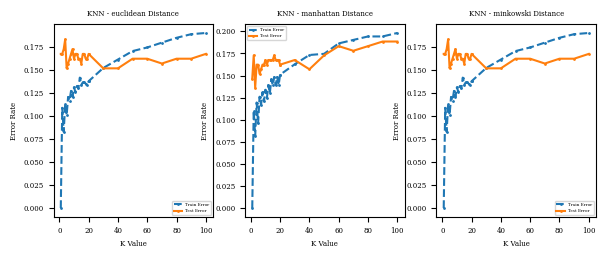

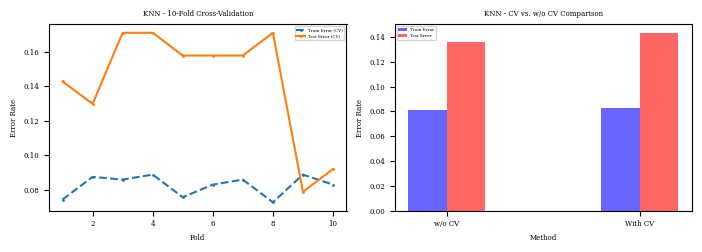

In [41]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Create results directory
results_dir = "KNN"
os.makedirs(results_dir, exist_ok=True)

# Load processed dataset
train_df = pd.read_csv("train_processed.csv")
test_df = pd.read_csv("test_processed.csv")

# Extract features and target variable
X_train = train_df.drop(columns=['popularity']).values
y_train = train_df['popularity'].values
X_test = test_df.drop(columns=['popularity']).values
y_test = test_df['popularity'].values

# Define hyperparameters: K values and distance metrics
k_values = list(range(1, 21)) + list(range(20, 101, 10))
distance_metrics = ["euclidean", "manhattan", "minkowski"]

# Store KNN results and wall clock times
knn_results = {}
timing_results = []
training_errors_records = []  # Store training errors for all K values

# Measure execution time for hyperparameter tuning
for metric in distance_metrics:
    train_errors, test_errors = [], []
    start_time = time.time()  # Start timer
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        
        # Predictions
        train_pred = knn.predict(X_train)
        test_pred = knn.predict(X_test)
        
        # Compute error rates
        train_error = 1 - accuracy_score(y_train, train_pred)
        test_error = 1 - accuracy_score(y_test, test_pred)
        
        train_errors.append(train_error)
        test_errors.append(test_error)
        
        # Store errors for CSV
        training_errors_records.append({"K": k, "Metric": metric, "Train Error": train_error, "Test Error": test_error})

    elapsed_time = time.time() - start_time  # End timer
    knn_results[metric] = {'train_errors': train_errors, 'test_errors': test_errors}
    timing_results.append({"Metric": metric, "Phase": "Hyperparameter Tuning", "Time (s)": elapsed_time})

# Save training errors for different K values
pd.DataFrame(training_errors_records).to_csv(os.path.join(results_dir, "Spotify_knn_training_errors.csv"), index=False)

# Find the best K and metric (based on lowest test error)**
best_metric, best_k = None, None
best_test_error, best_train_error = float('inf'), float('inf')

for metric in distance_metrics:
    min_error_idx = np.argmin(knn_results[metric]['test_errors'])
    if knn_results[metric]['test_errors'][min_error_idx] < best_test_error:
        best_test_error = knn_results[metric]['test_errors'][min_error_idx]
        best_train_error = knn_results[metric]['train_errors'][min_error_idx]
        best_metric = metric
        best_k = k_values[min_error_idx]
print(f"Best K: {best_k}, Best Metric: {best_metric}")
# **Train the Best KNN Model Separately (Non-CV, 50 epochs)**
start_time_non_cv = time.time()
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
best_knn.fit(X_train, y_train)
train_pred_non_cv = best_knn.predict(X_train)
test_pred_non_cv = best_knn.predict(X_test)
best_train_error_non_cv = 1 - accuracy_score(y_train, train_pred_non_cv)
best_test_error_non_cv = 1 - accuracy_score(y_test, test_pred_non_cv)
elapsed_time_non_cv = time.time() - start_time_non_cv

# Perform 10-Fold Cross-Validation using the best K and metric**
kf = KFold(n_splits=10, shuffle=True, random_state=1024)
cv_train_errors, cv_test_errors = [], []

start_time_cv = time.time()  # Start timer for CV

for train_idx, val_idx in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn.fit(X_train_fold, y_train_fold)

    train_pred = knn.predict(X_train_fold)
    test_pred = knn.predict(X_val_fold)

    cv_train_errors.append(1 - accuracy_score(y_train_fold, train_pred))
    cv_test_errors.append(1 - accuracy_score(y_val_fold, test_pred))

elapsed_time_cv = time.time() - start_time_cv  # End timer for CV
cv_train_error_mean = np.mean(cv_train_errors)
cv_test_error_mean = np.mean(cv_test_errors)

# Save full results (non-CV and CV) to a single CSV**
full_results = [
    {
        "Metric": best_metric,
        "Best K": best_k,
        "Phase": "Non-CV Training",
        "Train_Error": best_train_error_non_cv,
        "Test_Error": best_test_error_non_cv,
        "Time(s)": elapsed_time_non_cv
    },
    {
        "Metric": best_metric,
        "Best K": best_k,
        "Phase": "Cross-Validation",
        "Train_Error": cv_train_error_mean,
        "Test_Error": cv_test_error_mean,
        "Time(s)": elapsed_time_cv
    }
]

pd.DataFrame(full_results).to_csv(os.path.join(results_dir, "Spotify_knn_log.csv"), index=False)

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})


# **Plot KNN hyperparameter tuning results (Unified Y-axis)**
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
for i, metric in enumerate(distance_metrics):
    axes[i].plot(k_values, knn_results[metric]['train_errors'], label="Train Error", linestyle='dashed', marker='o')
    axes[i].plot(k_values, knn_results[metric]['test_errors'], label="Test Error", marker='o')
    axes[i].set_title(f"KNN - {metric} Distance")
    axes[i].set_xlabel("K Value")
    axes[i].set_ylabel("Error Rate")
    axes[i].legend()
plt.savefig(os.path.join(results_dir, "Spotify_knn_k_vs_error.png"))
plt.show()

# **Plot K-Fold CV results & Final Comparison**
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# Left Plot: K-Fold CV errors
axes[0].plot(range(1, 11), cv_train_errors, label="Train Error (CV)", linestyle='dashed', marker='o')
axes[0].plot(range(1, 11), cv_test_errors, label="Test Error (CV)", marker='o')
axes[0].set_title("KNN - 10-Fold Cross-Validation")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Error Rate")
axes[0].legend()

# **Right Plot: No-CV vs. CV Bar Chart**
x_labels = ["w/o CV", "With CV"]
x = np.arange(len(x_labels))
width = 0.2
axes[1].bar(x - width/2, [best_train_error_non_cv, cv_train_error_mean], width, label="Train Error", color='b', alpha=0.6)
axes[1].bar(x + width/2, [best_test_error_non_cv, cv_test_error_mean], width, label="Test Error", color='r', alpha=0.6)
axes[1].set_title("KNN - CV vs. w/o CV Comparison")
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Error Rate")
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels)
axes[1].legend()
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "Spotify_knn_final_comparison.png"),dpi = 300)
plt.show()


## SVM Model Training and Evaluation Structure

This code follows a typical structure for model training and evaluation:

### 4.1 **Setup & Data Loading**
   - Set random seed for reproducibility.
   - Create a directory to save results.
   - Load and preprocess training/testing data from CSV files.

### 4.2 **Model Configuration & Training**
   - Define different configurations for the SVM model (various kernels and C values).
   - Train the SVM for each configuration and compute error rates on train/test sets.

### 4.3 **Performance Analysis**
   - Plot learning curves for different kernels.
   - Evaluate the effect of different C values on model performance.
   - Use 10-fold cross-validation to assess model stability and compare with non-CV training.

### 4.4 **Results & Saving**
   - Save plots visualizing error rates and comparisons.
   - Log training times and error rates into a CSV file.

Best Kernel: linear


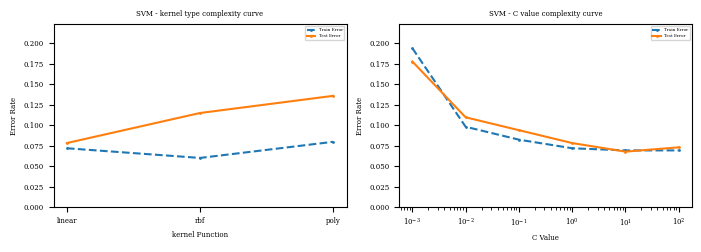

Best C: 10


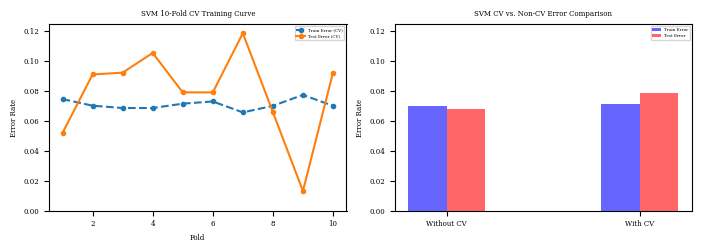

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve, cross_val_score, KFold

# Set random seed to match DNN configuration
def set_seed(seed=1024):
    random.seed(seed)
    np.random.seed(seed)

set_seed(1024)

# Create results directory
results_dir = "SVM"
os.makedirs(results_dir, exist_ok=True)

# Load training & testing data
train_df = pd.read_csv("train_processed.csv")
test_df = pd.read_csv("test_processed.csv")

# Extract features and labels
X_train = train_df.drop(columns=['popularity']).values
y_train = train_df['popularity'].values
X_test = test_df.drop(columns=['popularity']).values
y_test = test_df['popularity'].values

# Define SVM kernels & C values
kernels = ["linear", "rbf", "poly"]
C_values = [0.001,0.01, 0.1, 1, 10,100]
train_sizes = np.linspace(0.1, 1.0, 10)

# Store all training & test errors

# 1️ First Set of Plots: Learning Curves for Different Kernels (Ensure same y-scale)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

kernel_train_error, kernel_test_error = [], []

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})

for i, kernel in enumerate(kernels):
    model = SVC(kernel=kernel, C=1.0, random_state=1024)
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    train_error = 1 - train_accuracy 
    test_error = 1 - test_accuracy 

    kernel_train_error.append(train_error)  
    kernel_test_error.append(test_error)  
kernels_logs = {'kernels': kernels, 'train_errors': kernel_train_error, 'test_errors': kernel_test_error}
pd.DataFrame(kernels_logs).to_csv(os.path.join(results_dir, "Spotify_SVM_kernels_log.csv"), index=False)
k_y_min, k_y_max = min(0, min(kernel_test_error), min(kernel_train_error)), max( max(kernel_test_error), max(kernel_train_error))
axes[0].plot(kernels, kernel_train_error, label="Train Error", linestyle="dashed", marker="o")
axes[0].plot(kernels, kernel_test_error, label="Test Error", marker="o")
axes[0].set_title(f"SVM - kernel type complexity curve")
axes[0].set_xlabel("kernel Function")
axes[0].set_ylabel("Error Rate")
axes[0].legend()

best_kernel = kernels[np.argmin(kernel_test_error)]
print(f"Best Kernel: {best_kernel}")
# 2️ Second Set of Plots: Training Size vs. Error for Different C Values (Ensure same y-scale)
# -----------------------------------------------------------------------------
c_train_error, c_test_error = [], []
for i, c in enumerate(C_values):
    model = SVC(kernel=best_kernel, C=c, random_state=1024)
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    train_error = 1 - train_accuracy 
    test_error = 1 - test_accuracy 

    c_train_error.append(train_error)  
    c_test_error.append(test_error)  

c_logs = {'C_values': C_values, 'train_errors': c_train_error, 'test_errors': c_test_error}
pd.DataFrame(c_logs).to_csv(os.path.join(results_dir, "Spotify_SVM_C_values_log.csv"), index=False)
C_str = [str(c) for c in C_values]
c_y_min, c_y_max = min(0, min(c_test_error), min(c_train_error)), max( max(c_test_error), max(c_train_error))
axes[1].plot(C_values, c_train_error, label="Train Error", linestyle="dashed", marker="o")
axes[1].plot(C_values, c_test_error, label="Test Error", marker="o")
plt.xscale("log")
axes[1].set_title(f"SVM - C value complexity curve")
axes[1].set_xlabel("C Value")
axes[1].set_ylabel("Error Rate")
axes[1].legend()

y_min, y_max = min(k_y_min, k_y_min), max(c_y_max, c_y_max)
for ax in axes:
    ax.set_ylim(y_min * 0.85, y_max * 1.15)
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "Spotify_SVM_complexity curcve.png"), dpi=300)
plt.show()

best_c = C_values[np.argmin(c_test_error)]
print(f"Best C: {best_c}")
# 3 Third Set of Plots: Cross-Validation & Complexity Analysis (Ensure same y-scale)
# -----------------------------------------------------------------------------
C_best = best_c
kernel_best = best_kernel  # Assume the best kernel

# non-cv
start_time_non_cv = time.time()
svm_no_cv = SVC(kernel=kernel_best, C=C_best, random_state=1024)
svm_no_cv.fit(X_train, y_train)
end_time_non_cv = time.time()
non_cv_time = end_time_non_cv - start_time_non_cv
non_cv_train_error = 1 - svm_no_cv.score(X_train, y_train)
non_cv_test_error = 1 - svm_no_cv.score(X_test, y_test)

#cv
kf = KFold(n_splits=10, shuffle=True, random_state=1024)
start_time_cv = time.time()

cv_model = SVC(kernel=kernel_best, C=C_best, random_state=1024)
cv_test_scores = cross_val_score(cv_model, X_train, y_train, cv=kf, scoring="accuracy")
cv_test_error = 1 - np.mean(cv_test_scores)

cv_train_errors = []
for train_idx, val_idx in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    cv_model.fit(X_train_fold, y_train_fold)
    train_accuracy = cv_model.score(X_train_fold, y_train_fold)
    cv_train_errors.append(1 - train_accuracy)

cv_train_error = np.mean(cv_train_errors)

end_time_cv = time.time()
cv_time = end_time_cv - start_time_cv

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# 1️ 10-Fold CV
axes[0].plot(range(1, 11), cv_train_errors, linestyle="dashed", marker="o", markersize = 3,label="Train Error (CV)")
axes[0].plot(range(1, 11), 1 - cv_test_scores, marker="o",markersize = 3, linestyle="-", label="Test Error (CV)")
axes[0].set_title("SVM 10-Fold CV Training Curve")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Error Rate")
axes[0].legend()

# 2️ Non-CV vs. CV
labels = ["Without CV", "With CV"]
x = np.arange(len(labels))
width = 0.2
axes[1].bar(x - width/2, [non_cv_train_error, cv_train_error], width, label="Train Error", color='b', alpha=0.6)
axes[1].bar(x + width/2, [non_cv_test_error, cv_test_error], width, label="Test Error", color='r', alpha=0.6)
axes[1].set_title("SVM CV vs. Non-CV Error Comparison")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Error Rate")
axes[1].legend()

y_min_2, y_max_2 = min(0, min(cv_train_errors), min(1 - cv_test_scores)), max(max(cv_train_errors), max(1 - cv_test_scores))

for ax in axes:
    ax.set_ylim(y_min_2 * 0.85, y_max_2 * 1.05)
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "Spotify_SVM_final_analysis.png"), dpi=300)
plt.show()

# save
time_log_df = pd.DataFrame({
    "Model": ["Non-CV", "CV"],
    "Time(s)": [non_cv_time, cv_time],
    "Train_Error": [non_cv_train_error, cv_train_error],
    "Test_Error": [non_cv_test_error, cv_test_error]
})
time_log_df.to_csv(os.path.join(results_dir, "SVM_log.csv"), index=False)


## 5. Model Comparison Analysis
This section presents a comparative analysis of Deep Neural Networks (DNNs), Support Vector Machines (SVMs), and K-Nearest Neighbors (KNNs) in terms of training time and model performance.

### 5.1 Setup and Data Loading
A results directory Model_Comparison is created to store outputs.
Training logs for DNN, SVM, and KNN are loaded from CSV files.
KNN logs are split into Non-CV Training and Cross-Validation phases for separate analysis.
### 5.2 Key Metrics Extraction
Wall Clock Training Time: Extracted for both non-cross-validation (Non-CV) and cross-validation (CV) phases.
Model Performance (Error Rates):
Training Error (Non-CV vs. CV)
Test Error (Non-CV vs. CV)
Why Compare These?
Evaluating the trade-off between computational cost and generalization.
Checking how cross-validation affects error rates.
### 5.3 Visualization
(1) Wall Clock Time Comparison
Compares training times across models (DNN, SVM, KNN) for both Non-CV and CV.
Uses a logarithmic scale to accommodate differences in scale.
Expected trends:
CV takes significantly longer than Non-CV due to repeated training.
DNN is typically more computationally expensive than SVM and KNN.
(2) Train & Test Error Comparison
Compares train & test errors across models.
Each model has four bars:
Non-CV Train Error
CV Train Error
Non-CV Test Error
CV Test Error
### 5.4 Saving and Displaying Results
The final figure is saved as final_model_comparison.png.

<>:12: SyntaxWarning: invalid escape sequence '\G'
<>:13: SyntaxWarning: invalid escape sequence '\G'
<>:12: SyntaxWarning: invalid escape sequence '\G'
<>:13: SyntaxWarning: invalid escape sequence '\G'
C:\Users\louis\AppData\Local\Temp\ipykernel_56288\224903300.py:12: SyntaxWarning: invalid escape sequence '\G'
  svm_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\SVM\SVM_log.csv")
C:\Users\louis\AppData\Local\Temp\ipykernel_56288\224903300.py:13: SyntaxWarning: invalid escape sequence '\G'
  knn_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\KNN\Spotify_knn_log.csv")


non_cv_train_time: [np.float64(1.1566569805145264), np.float64(0.0907812118530273), np.float64(0.0515134334564209)]
cv_train_time: [np.float64(10.071396589279177), np.float64(0.0786418914794921), np.float64(0.7937860488891602)]


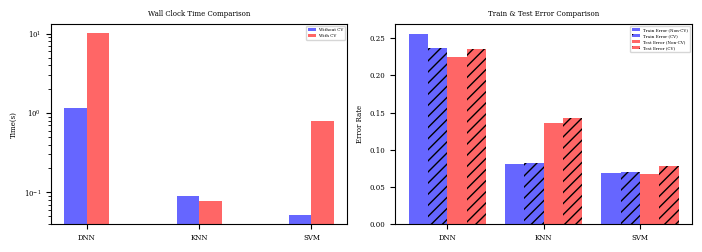

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set the results directory
results_dir = "Model_Comparison"
os.makedirs(results_dir, exist_ok=True)

# Load the training logs
dnn_log = pd.read_csv(r"D:\Gatech\CS7641 Machine Learning\A1\NN\dnn_log.csv")
svm_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\SVM\SVM_log.csv")
knn_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\KNN\Spotify_knn_log.csv")

# Extract Non-CV & CV data
models = ["DNN", "KNN", "SVM"]

# Extract KNN logs (handling different format)
knn_non_cv = knn_log[knn_log["Phase"] == "Non-CV Training"]
knn_cv = knn_log[knn_log["Phase"] == "Cross-Validation"]

# Extract training times
non_cv_train_time = [
    dnn_log.loc[dnn_log["Model"] == "Non-CV", "Time(s)"].values[0],
    knn_non_cv["Time(s)"].values[0],
    svm_log.loc[svm_log["Model"] == "Non-CV", "Time(s)"].values[0],
]

cv_train_time = [
    dnn_log.loc[dnn_log["Model"] == "CV", "Time(s)"].values[0],
    knn_cv["Time(s)"].values[0],
    svm_log.loc[svm_log["Model"] == "CV", "Time(s)"].values[0],
]

# Extract train/test error rates
non_cv_train_error = [
    dnn_log.loc[dnn_log["Model"] == "Non-CV", "Train_Error"].values[0],
    knn_non_cv["Train_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "Non-CV", "Train_Error"].values[0],
]

cv_train_error = [
    dnn_log.loc[dnn_log["Model"] == "CV", "Train_Error"].values[0],
    knn_cv["Train_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "CV", "Train_Error"].values[0],
]

non_cv_test_error = [
    dnn_log.loc[dnn_log["Model"] == "Non-CV", "Test_Error"].values[0],
    knn_non_cv["Test_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "Non-CV", "Test_Error"].values[0],
]

cv_test_error = [
    dnn_log.loc[dnn_log["Model"] == "CV", "Test_Error"].values[0],
    knn_cv["Test_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "CV", "Test_Error"].values[0],
]

final_logs = {'models': models, 'non_cv_train_time': non_cv_train_time, 'cv_train_time': cv_train_time, 'non_cv_train_error': non_cv_train_error, 'cv_train_error': cv_train_error, 'non_cv_test_error': non_cv_test_error, 'cv_test_error': cv_test_error}
pd.DataFrame(final_logs).to_csv(os.path.join(results_dir, "Spotify_final_model_comparison.csv"), index=False)

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))
# 1️. Training Time Comparison (per model: Non-CV & CV)
x = np.arange(len(models))
width = 0.2

axes[0].bar(x - width/2, non_cv_train_time, width, color='blue', alpha=0.6, label="Without CV")
axes[0].bar(x + width/2, cv_train_time, width, color='red', alpha=0.6, label="With CV")
axes[0].set_yscale('log')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("Wall Clock Time Comparison")
axes[0].set_ylabel("Time(s)")
axes[0].legend()
print('non_cv_train_time:', non_cv_train_time)
print('cv_train_time:', cv_train_time)

# 2️. Train & Test Error Comparison
x = np.arange(len(models))
# width = 0.2

axes[1].bar(x - width, non_cv_train_error, width, label="Train Error (Non-CV)", color="blue", alpha=0.6)
axes[1].bar(x, cv_train_error, width, label="Train Error (CV)", color="blue", hatch="///", alpha=0.6)
axes[1].bar(x + width, non_cv_test_error, width, label="Test Error (Non-CV)", color="red", alpha=0.6)
axes[1].bar(x + 2*width, cv_test_error, width, label="Test Error (CV)", color="red", hatch="///", alpha=0.6)

axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(models)
axes[1].set_title("Train & Test Error Comparison")
axes[1].set_ylabel("Error Rate")
axes[1].legend()

# Save and show plots
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "Spotify_final_model_comparison.png"), dpi=300)
plt.show()
